# Chempiler — Analysis Walkthrough

**Chempiler** is a Python package for chemical perception and analysis of reactive molecular dynamics (MD) trajectories.
Unlike conventional MD analysis tools, chempiler rebuilds molecular topology from scratch for every frame,
making it correct for reactive force-field simulations (e.g. ReaxFF) where bonds break and form throughout the run.

This notebook walks through the main capabilities:

| Section | What it covers |
|---|---|
| 1 | Loading a trajectory and HDF5 caching |
| 2 | Inspecting the chemical composition |
| 3 | Trajectory segmentation |
| 4 | Radial distribution function (RDF) |
| 5 | Atom-hop tracking (proton transfer) |
| 6 | Ligand-exchange and coordination dynamics |
| 7 | Block-averaging statistics |
| 8 | Custom tracking with the low-level `Tracker` API |

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

---
## 1 — Loading a trajectory

`ChempilerTrajectory` accepts any ASE-readable file format (`.traj`, `.xyz`, LAMMPS dump, etc.).
Calling `.build()` performs chemical perception on every frame: atoms are grouped into molecules
by distance-based bond detection using scaled ASE covalent radii.

### HDF5 caching

Perception is the most expensive step — rebuilding all molecules for 4000 frames takes seconds to minutes
depending on system size. Pass a `cache_file` path and the result is serialised to HDF5 on the first run
and reloaded instantly on every subsequent run. The cache is invalidated automatically if any perception
parameter changes.

In [3]:
from chempiler import ChempilerTrajectory

traj = ChempilerTrajectory(
    "tests/39_water_OH.traj",
    mode="molecular",       # detect covalent bonds
    covalent_scale=1.0,     # exact ASE natural cutoffs
)

traj.build(cache_file="tests/cache_file.h5")

frames = traj.frames
print(f"Loaded {len(frames)} frames")
print(f"Atoms per frame : {len(frames[0].atoms)}")
print(f"Molecules in frame 0 : {len(frames[0].molecules)}")

[Chempiler] loaded cache → tests/cache_file.h5
Loaded 4000 frames
Atoms per frame : 119
Molecules in frame 0 : 37


The `[Chempiler] loaded cache` message confirms that the HDF5 file was found and used.
Running the cell a second time will always load from cache — the build step is skipped entirely.

Each `Frame` object exposes:
- `frame.atoms` — the raw ASE `Atoms` object (positions, cell, PBC)
- `frame.molecules` — list of atom-index lists, one per molecule
- `frame.formulas` — list of formula strings parallel to `molecules`
- `frame.symbols` — element symbol per atom
- `frame.atom_to_mol` — int32 array mapping each atom index to its molecule index

---
## 2 — Chemical composition

`traj.summary()` returns how many times each molecular formula appears across all frames.
In a stable trajectory this is roughly `n_frames × count_per_frame` for each species;
large imbalances between formulas signal reaction events.

In [4]:
summary = traj.summary()

# Sort by count so the dominant species appear first
for formula, count in sorted(summary.items(), key=lambda x: -x[1]):
    avg_per_frame = count / len(frames)
    print(f"  {formula:<8}  total={count:>8}   avg/frame={avg_per_frame:.2f}")

  H2O       total=  149623   avg/frame=37.41
  H3O2      total=    1851   avg/frame=0.46
  H4O2      total=    1542   avg/frame=0.39
  HO        total=    1507   avg/frame=0.38
  H5O3      total=     580   avg/frame=0.14
  H7O4      total=      59   avg/frame=0.01
  H6O3      total=      28   avg/frame=0.01
  H9O5      total=       2   avg/frame=0.00
  H8O4      total=       2   avg/frame=0.00
  H11O6     total=       1   avg/frame=0.00


**Interpretation:** `H2O` will be the dominant species. Smaller counts of `HO` (hydroxide) or `H3O` (hydronium)
indicate transient proton-transfer intermediates. Because molecular identity is rebuilt each frame,
any frame where an O atom briefly picks up a second H registers as `H3O`, and any frame where it
loses one registers as `HO`.

We can also inspect the composition of a single frame more directly:

In [5]:
from collections import Counter

frame0 = frames[0]
counts = Counter(frame0.formulas)

print("Frame 0 composition:")
for formula, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {formula}: {n}")

# Show which atoms belong to the first H2O molecule
mol_id = frame0.formula_to_mols["H2O"][0]
atom_indices = frame0.atoms_in_mol(mol_id)
print(f"\nFirst H2O molecule → atom indices {atom_indices}")
for a in atom_indices:
    print(f"  atom {a}: {frame0.symbols[a]} at {frame0.positions[a]}")

Frame 0 composition:
  H2O: 35
  H6O3: 1
  H3O2: 1

First H2O molecule → atom indices [3, 4, 5]
  atom 3: O at [8.97507808 8.26654569 7.03409574]
  atom 4: H at [9.6725398  7.84627457 7.56164829]
  atom 5: H at [8.25892464 7.63523969 7.06782339]


### Molecule count over time

Plotting the total number of molecules per frame is a quick sanity check:
a flat line means nothing reacted; a step change means a reaction happened.

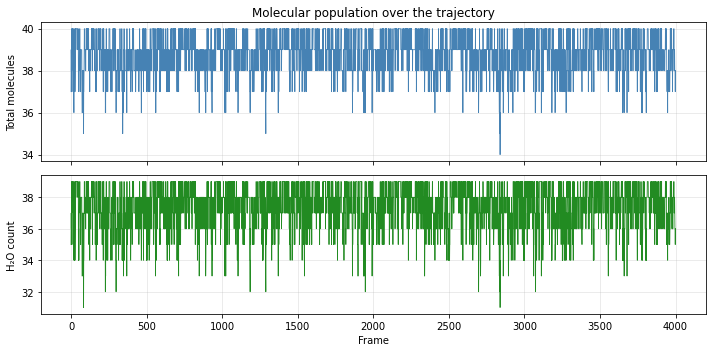

In [6]:
mol_counts = [len(f.molecules) for f in frames]
h2o_counts = [f.formulas.count("H2O") for f in frames]

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].plot(mol_counts, lw=0.8, color="steelblue")
axes[0].set_ylabel("Total molecules")
axes[0].set_title("Molecular population over the trajectory")

axes[1].plot(h2o_counts, lw=0.8, color="forestgreen")
axes[1].set_ylabel("H₂O count")
axes[1].set_xlabel("Frame")

plt.tight_layout()
plt.show()

**Interpretation:** In a bulk water simulation run with a reactive force field you typically see the H₂O
count fluctuate by ±1–2 around the starting value, reflecting transient proton-transfer states where
one molecule momentarily becomes H₃O⁺ and another OH⁻. A sustained drop would indicate a genuine
dissociation event.

---
## 3 — Trajectory segmentation

For long trajectories that contain a clear reaction (e.g. an acid–base neutralisation) it is useful
to split the run into segments of roughly constant composition before computing time averages.
`segment_by_molecule_count` does this by dividing the trajectory into non-overlapping blocks and
looking for a step change in the mean molecule count between adjacent blocks.

In [7]:
from chempiler.segmentation import segment_by_molecule_count

segments = segment_by_molecule_count(
    frames,
    block=50,       # frames averaged per block when searching for boundaries
    threshold=0.5,  # minimum change in mean molecule count to declare a new segment
)

print(f"Found {len(segments)} segment(s):")
for i, (start, end) in enumerate(segments):
    n_frames_seg = end - start
    avg_mols = np.mean(mol_counts[start:end])
    print(f"  Segment {i}: frames [{start}, {end})  ({n_frames_seg} frames)  avg mols = {avg_mols:.2f}")

Found 17 segment(s):
  Segment 0: frames [0, 50)  (50 frames)  avg mols = 38.90
  Segment 1: frames [50, 100)  (50 frames)  avg mols = 38.10
  Segment 2: frames [100, 300)  (200 frames)  avg mols = 38.84
  Segment 3: frames [300, 350)  (50 frames)  avg mols = 37.90
  Segment 4: frames [350, 950)  (600 frames)  avg mols = 38.67
  Segment 5: frames [950, 1000)  (50 frames)  avg mols = 39.44
  Segment 6: frames [1000, 1100)  (100 frames)  avg mols = 39.06
  Segment 7: frames [1100, 1300)  (200 frames)  avg mols = 38.56
  Segment 8: frames [1300, 1450)  (150 frames)  avg mols = 39.19
  Segment 9: frames [1450, 2150)  (700 frames)  avg mols = 38.83
  Segment 10: frames [2150, 2450)  (300 frames)  avg mols = 38.90
  Segment 11: frames [2450, 2650)  (200 frames)  avg mols = 39.02
  Segment 12: frames [2650, 2800)  (150 frames)  avg mols = 38.62
  Segment 13: frames [2800, 2850)  (50 frames)  avg mols = 37.84
  Segment 14: frames [2850, 3050)  (200 frames)  avg mols = 38.74
  Segment 15: frame

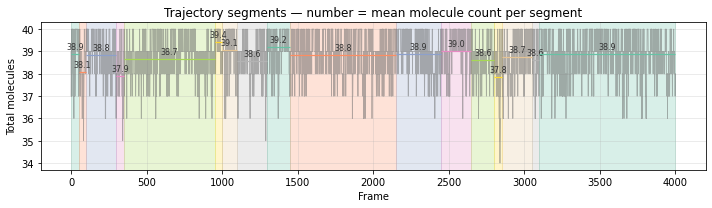

In [8]:
colors = plt.cm.Set2.colors

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(mol_counts, lw=0.8, color="0.4", zorder=2, alpha=0.5)

for i, (start, end) in enumerate(segments):
    avg = np.mean(mol_counts[start:end])
    ax.axvspan(start, end, alpha=0.25, color=colors[i % len(colors)])
    # horizontal mean line
    ax.hlines(avg, start, end, color=colors[i % len(colors)], lw=1.2, zorder=3)
    # annotate with mean value at the midpoint of the span
    mid = (start + end) / 2
    ax.text(mid, avg + 0.12, f"{avg:.1f}",
            ha="center", va="bottom", fontsize=8, color="0.2")

ax.set_xlabel("Frame")
ax.set_ylabel("Total molecules")
ax.set_title("Trajectory segments — number = mean molecule count per segment")
plt.tight_layout()
plt.show()

**Note:** `segment_by_molecule_count` detects changes in the *total* number of molecules.
It will not detect isodesmic reactions (e.g. H₃O⁺ + OH⁻ → 2 H₂O) because those conserve
the count. For finer-grained reaction detection, see `ligand_exchange` and `coordination_dynamics` in section 6.

### Per-species lifetime segments

`segment_by_molecule_count` detects *total-count* changes. For reactive species (HO, H3O, etc.)
that only exist for short intervals, `lifetime_segments` returns the contiguous frame intervals
where the formula is present — one tuple `(start, end)` per connected run.

In [9]:
ho_segs = traj.lifetime_segments("HO")

print(f"HO present in {len(ho_segs)} segment(s):")
for i, (s, e) in enumerate(ho_segs):
    print(f"  [{s:>5}, {e:>5})  — {e-s} frames")

total_ho_frames = sum(e - s for s, e in ho_segs)
print(f"\nHO present in {total_ho_frames} / {len(frames)} frames ({100*total_ho_frames/len(frames):.1f}%)")

HO present in 509 segment(s):
  [    1,     2)  — 1 frames
  [    5,     6)  — 1 frames
  [    7,    13)  — 6 frames
  [   14,    15)  — 1 frames
  [   25,    26)  — 1 frames
  [   29,    30)  — 1 frames
  [   31,    32)  — 1 frames
  [   33,    44)  — 11 frames
  [   47,    48)  — 1 frames
  [   58,    59)  — 1 frames
  [   88,    91)  — 3 frames
  [   92,    94)  — 2 frames
  [  100,   102)  — 2 frames
  [  103,   109)  — 6 frames
  [  110,   114)  — 4 frames
  [  116,   117)  — 1 frames
  [  118,   120)  — 2 frames
  [  135,   136)  — 1 frames
  [  138,   147)  — 9 frames
  [  148,   150)  — 2 frames
  [  158,   161)  — 3 frames
  [  169,   170)  — 1 frames
  [  174,   175)  — 1 frames
  [  176,   188)  — 12 frames
  [  189,   190)  — 1 frames
  [  192,   193)  — 1 frames
  [  195,   196)  — 1 frames
  [  197,   198)  — 1 frames
  [  199,   200)  — 1 frames
  [  201,   202)  — 1 frames
  [  203,   213)  — 10 frames
  [  214,   220)  — 6 frames
  [  221,   222)  — 1 frames
  [  223, 

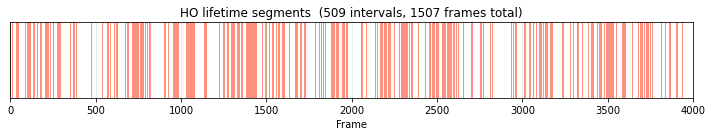

In [10]:
fig, ax = plt.subplots(figsize=(10, 2))
for s, e in ho_segs:
    ax.axvspan(s, e, color="tomato", alpha=0.7, lw=0)
ax.set_xlim(0, len(frames))
ax.set_xlabel("Frame")
ax.set_yticks([])
ax.set_title(f"HO lifetime segments  ({len(ho_segs)} intervals, {total_ho_frames} frames total)")
plt.tight_layout()
plt.show()

### Mean squared displacement (MSD)

`traj.msd(formula)` computes MSD(τ) = ⟨|r(t+τ) − r(t)|²⟩ for any species selectable from
`traj.summary()`. Molecules are tracked within each lifetime segment using minimum-image
nearest-neighbour COM matching; unwrapped trajectories are built frame-by-frame and combined
with the standard windowed estimator.

- For a **stable species** (H₂O) the slope at long lags gives the diffusion coefficient:
  D = MSD / (6τ).
- For a **transient species** (HO) only the short-time regime is accessible because each
  segment is short; the curve shows local mobility rather than long-range diffusion.

In [11]:
import warnings

# H2O: long-lived species — no warning expected
lags_w, msd_w, n_w = traj.msd("H2O", max_lag=500, correlation_time=50)

# HO: transient species — warn if segments shorter than correlation_time * buffer
# correlation_time=10 frames, buffer=5 → threshold = 50 frames
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    lags_ho, msd_ho, n_ho_msd = traj.msd("HO", correlation_time=10)

for w in caught:
    print(f"Warning: {w.message}")

print(f"\nH2O: {len(lags_w)} lag points,  max_lag = {lags_w[-1]} frames")
print(f"HO : {len(lags_ho)} lag points,  max_lag = {lags_ho[-1]} frames")


H2O: 500 lag points,  max_lag = 500 frames
HO : 22 lag points,  max_lag = 22 frames


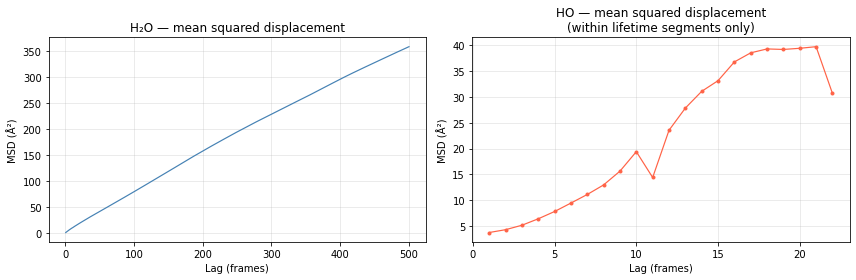

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# H2O
axes[0].plot(lags_w, msd_w, color="steelblue", lw=1.2)
axes[0].set_xlabel("Lag (frames)")
axes[0].set_ylabel("MSD (Å²)")
axes[0].set_title("H₂O — mean squared displacement")

# HO — may have few points if segments are short
axes[1].plot(lags_ho, msd_ho, color="tomato", lw=1.2,
             marker="o", ms=3, markevery=max(1, len(lags_ho)//20))
axes[1].set_xlabel("Lag (frames)")
axes[1].set_ylabel("MSD (Å²)")
axes[1].set_title("HO — mean squared displacement\n(within lifetime segments only)")

plt.tight_layout()
plt.show()

---
## 4 — Radial distribution function (RDF)

The RDF $g(r)$ describes how atomic density varies as a function of distance from a reference atom.
A peak at distance $r$ means that target atoms preferentially sit at that separation from the center atoms.

Chempiler computes RDFs correctly under periodic boundary conditions using ASE's `find_mic`
(minimum image convention). Selectors are resolved fresh for each frame, so changing populations
(reactions) are handled correctly.

### Selector syntax

| Selector | Meaning |
|---|---|
| `"O"` | All oxygen atoms |
| `"H"` | All hydrogen atoms |
| `{"H2O": "O"}` | O atoms that are inside an H₂O molecule |
| `{"H2O": None}` | All atoms inside H₂O molecules |

In [13]:
# O–H RDF: the first peak is the O–H covalent bond (~1 Å),
# the second peak is the hydrogen-bond donor distance (~1.8 Å).
# integrate=True also returns n(r) in the same pass — no second call needed.
r_oh, g_oh, n_oh = traj.rdf(center="O", target="H", dr=0.02, integrate=True)

# O–O RDF: the first peak at ~2.8 Å is the hydrogen-bond O–O distance
r_oo, g_oo = traj.rdf(center="O", target="O", dr=0.05)

[RDF] rmax = 5.186 Å (auto)
[RDF] rmax = 5.186 Å (auto)


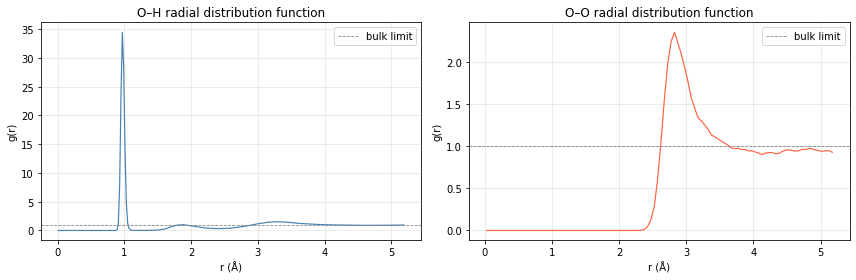

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(r_oh, g_oh, color="steelblue", lw=1.2)
axes[0].axhline(1.0, color="0.5", lw=0.8, ls="--", label="bulk limit")
axes[0].set_xlabel("r (Å)")
axes[0].set_ylabel("g(r)")
axes[0].set_title("O–H radial distribution function")
axes[0].legend()

axes[1].plot(r_oo, g_oo, color="tomato", lw=1.2)
axes[1].axhline(1.0, color="0.5", lw=0.8, ls="--", label="bulk limit")
axes[1].set_xlabel("r (Å)")
axes[1].set_ylabel("g(r)")
axes[1].set_title("O–O radial distribution function") 
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation:**
- **O–H:** The sharp peak near 1 Å is the covalent O–H bond. The broader peak around 1.8 Å corresponds
  to hydrogen-bond donated H atoms. Both peaks should sit well above 1 (the ideal-gas baseline).
- **O–O:** The peak near 2.8 Å is the characteristic hydrogen-bond O–O distance in liquid water;
  the second shell appears around 4.5 Å. $g(r) \to 1$ at large $r$ confirms the simulation is large
  enough that the correlations die out before the box boundary.

### Running coordination number

Setting `integrate=True` returns the cumulative integral $n(r) = 4\pi\rho \int_0^r g(r') r'^2 dr'$,
the average number of target atoms within distance $r$ of each center atom.
The value of $n(r)$ at the first minimum gives the mean first-shell coordination number.

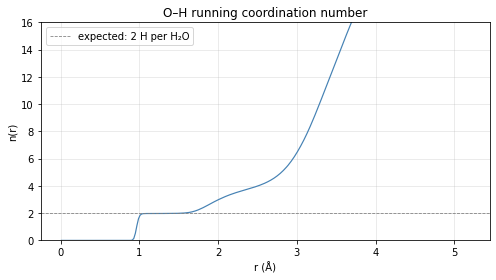

Average covalent O–H coordination number (r < 1.4 Å): 1.98


In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r_oh, n_oh, color="steelblue", lw=1.2)
ax.axhline(2.0, color="0.5", lw=0.8, ls="--", label="expected: 2 H per H₂O")
ax.set_xlabel("r (Å)")
ax.set_ylabel("n(r)")
ax.set_ylim(0, 16)
ax.set_title("O–H running coordination number")
ax.legend()
plt.tight_layout()
plt.show()

# Read off the coordination number at the first minimum (just past the covalent-bond peak)
mask = r_oh < 1.4
cn_covalent = n_oh[mask][-1]
print(f"Average covalent O–H coordination number (r < 1.4 Å): {cn_covalent:.2f}")

**Interpretation:** The plateau near $n = 2$ at $r \approx 1.2$ Å confirms that each oxygen has on
average two covalently bonded hydrogens — consistent with a mostly H₂O population. A value slightly
below 2 would indicate a small fraction of OH⁻ anions.

---
## 5 — Atom-hop tracking

`atom_hop` tracks the transfer of a mobile species (default: `H`) between host atoms (default: `O`).
The *state* of each tracked atom is the index of the nearest host within `cutoff` Å.
A hop is recorded whenever that index changes.

The `persistence` parameter is a noise filter: the new host must be observed for at least
`persistence` consecutive frames before the hop is committed. This suppresses spurious events
that arise when a hydrogen rattles back and forth across the cutoff boundary.

In [16]:
from chempiler.state_engine import atom_hop

result = atom_hop(
    frames,
    tracked="H",        # mobile species
    host="O",           # host species
    cutoff=1.25,        # Å — rough O–H covalent bond cutoff
    persistence=3,      # new host must hold for 3 frames
)

print(f"Total hop events : {result['n_transitions']}")
print(f"Frames in trajectory : {len(frames)}")

if result['n_transitions'] > 0:
    print("\nFirst 5 hop events (frame, H-atom, from-O, to-O):")
    for event in result['transitions'][:5]:
        frame_idx, h_idx, from_o, to_o = event
        print(f"  frame {frame_idx:>5}  H[{h_idx:>3}]  O[{from_o}] → O[{to_o}]")

Total hop events : 41
Frames in trajectory : 4000

First 5 hop events (frame, H-atom, from-O, to-O):
  frame     6  H[ 10]  O[9] → O[21]
  frame    59  H[ 10]  O[21] → O[9]
  frame    62  H[ 10]  O[9] → O[21]
  frame    70  H[ 10]  O[21] → O[9]
  frame    73  H[ 10]  O[9] → O[21]


Reactive H atoms  : 8 / 79
Median            : 154.0 frames
Mean              : 415.4 frames


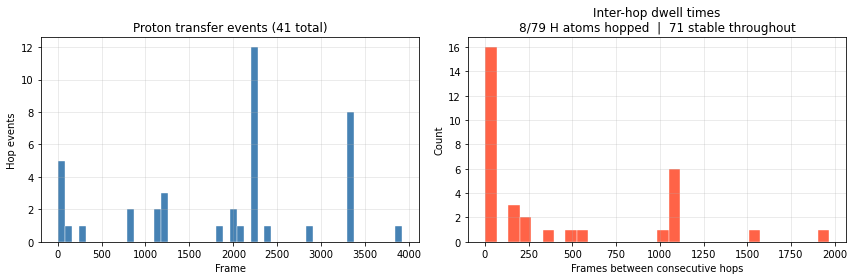

In [17]:
transitions = result['transitions']

# Map H-atom indices to their position in the residence_times array
syms = frames[0].symbols
h_indices = [i for i, s in enumerate(syms) if s == 'H']
atom_to_pos = {a: i for i, a in enumerate(h_indices)}

# Split into reactive (hopped ≥1 time) and stable atoms
hopped_atoms = set(t[1] for t in transitions)
n_total  = len(result['residence_times'])
n_hopped = len(hopped_atoms)
n_stable = n_total - n_hopped

# Inter-hop dwell times (requires ≥2 hops per atom)
from collections import defaultdict
hops_by_atom = defaultdict(list)
for frame_idx, atom_idx, _, _ in transitions:
    hops_by_atom[atom_idx].append(frame_idx)

dwell_times = np.array([
    t2 - t1
    for hop_frames in hops_by_atom.values()
    for t1, t2 in zip(hop_frames, hop_frames[1:])
])

# Final-state residence times for reactive atoms only (always available)
reactive_rt = np.array([
    result['residence_times'][atom_to_pos[a]]
    for a in hopped_atoms if a in atom_to_pos
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: hop events over time
if transitions:
    axes[0].hist([t[0] for t in transitions], bins=50,
                 color='steelblue', edgecolor='white', lw=0.4)
    axes[0].set_xlabel('Frame')
    axes[0].set_ylabel('Hop events')
    axes[0].set_title(f'Proton transfer events ({result["n_transitions"]} total)')
else:
    axes[0].text(0.5, 0.5, 'No hops detected', ha='center', va='center',
                 transform=axes[0].transAxes, fontsize=13, color='0.5')
    axes[0].set_title('Proton transfer events')

# Right: dwell times — inter-hop if available, else final-state for reactive atoms
subtitle = f'{n_hopped}/{n_total} H atoms hopped  |  {n_stable} stable throughout'
if len(dwell_times) > 0:
    plot_data = dwell_times
    xlabel = 'Frames between consecutive hops'
    title = f'Inter-hop dwell times\n{subtitle}'
else:
    plot_data = reactive_rt
    xlabel = 'Frames in final bonded state'
    title = f'Final-state residence — reactive H only\n{subtitle}'

if len(plot_data) > 0:
    axes[1].hist(plot_data, bins=30, color='tomato', edgecolor='white', lw=0.4)
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel('Count')
    axes[1].set_title(title)
    print(f'Reactive H atoms  : {n_hopped} / {n_total}')
    print(f'Median            : {np.median(plot_data):.1f} frames')
    print(f'Mean              : {plot_data.mean():.1f} frames')
else:
    axes[1].text(0.5, 0.5, 'No hops detected', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=13, color='0.5')
    axes[1].set_title(subtitle)

plt.tight_layout()
plt.show()

**Interpretation:**
- The **event histogram** shows when proton transfers are most frequent. A uniform distribution
  indicates diffuse, uncorrelated hopping (typical in liquid water). Bursts or gaps would point to
  collective or concerted mechanisms.
- The **residence-time distribution** is typically exponential for a Poisson process. A very short
  mean residence time (comparable to the time step) suggests the `cutoff` or `persistence` needs tuning.

### Tracking any mobile species

`atom_hop` is not limited to protons. The same function works for any mobile/host pair —
lithium hopping in a solid electrolyte, halide migration in a crystal, etc.

In [18]:
# Example: same call for a different system (Li hopping between O sites)
# result_li = atom_hop(frames, tracked="Li", host="O", cutoff=2.2, persistence=5)

# Here we just show the call signature; uncomment for the appropriate trajectory
print("atom_hop(frames, tracked='Li', host='O', cutoff=2.2, persistence=5)")
print("Returns the same dict: {'transitions', 'n_transitions', 'residence_times'}")

atom_hop(frames, tracked='Li', host='O', cutoff=2.2, persistence=5)
Returns the same dict: {'transitions', 'n_transitions', 'residence_times'}


### Distance from hop site to a target species

`hop_species_distances` cross-references the hop event list with the per-frame
molecular positions. For each hop where the target formula is present, it records
the distance from the hopping atom to the nearest molecule of that formula.
Hops occurring in frames where the target species is absent are skipped.

The `reference` argument controls which position is used as the hop site:
- `"H"` — the hopping atom itself (default)
- `"from"` — the donor host atom
- `"to"` — the acceptor host atom

Total hop events       : 41
Hops with HO present   : 7
Mean H→HO distance     : 4.44 Å
Min / Max distance     : 1.75 / 6.42 Å


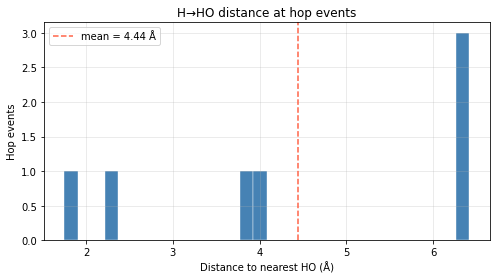

In [19]:
from chempiler.state_engine import hop_species_distances

d = traj.hop_species_distances(result, formula="HO", reference="H")

print(f"Total hop events       : {d['n_hops_total']}")
print(f"Hops with HO present   : {d['n_measured']}")
print(f"Mean H→HO distance     : {d['mean']:.2f} Å")

if d['n_measured'] > 0:
    print(f"Min / Max distance     : {d['distances'].min():.2f} / {d['distances'].max():.2f} Å")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(d['distances'], bins=30, color='steelblue', edgecolor='white', lw=0.4)
    ax.axvline(d['mean'], color='tomato', lw=1.5, ls='--', label=f"mean = {d['mean']:.2f} Å")
    ax.set_xlabel('Distance to nearest HO (Å)')
    ax.set_ylabel('Hop events')
    ax.set_title('H→HO distance at hop events')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No hop events coincided with an HO molecule being present.")

---
## 6 — Ligand exchange and coordination dynamics

These two functions use the internal per-frame tracker, which re-evaluates the entity set at every
frame. This is correct for reactive systems where molecules appear or disappear mid-trajectory.

### 6a — Ligand exchange

Tracks changes in molecular *formula*. A transition from `H2O` → `HO` means that molecule lost
a hydrogen (donated it to a neighbour); `H2O` → `H3O` means it gained one.

In [20]:
from chempiler.state_engine import ligand_exchange

lex = ligand_exchange(frames)

print(f"Ligand-exchange events: {lex['n_transitions']}")

if lex['n_transitions'] > 0:
    # Summarise which transitions actually occurred
    from collections import Counter
    transition_types = Counter(
        (from_f, to_f) for _, _, from_f, to_f in lex['transitions']
    )
    print("\nTransition types:")
    for (a, b), count in sorted(transition_types.items(), key=lambda x: -x[1]):
        print(f"  {a} → {b} : {count}")

Ligand-exchange events: 5179

Transition types:
  H2O → H4O2 : 1035
  H4O2 → H2O : 1020
  H2O → H3O2 : 540
  H3O2 → H2O : 520
  HO → H2O : 451
  H2O → HO : 434
  H5O3 → H2O : 184
  H2O → H5O3 : 176
  H3O2 → HO : 174
  HO → H3O2 : 170
  H3O2 → H5O3 : 129
  H5O3 → H3O2 : 108
  H5O3 → HO : 35
  HO → H5O3 : 25
  H6O3 → H2O : 20
  H5O3 → H7O4 : 19
  H7O4 → H2O : 17
  H2O → H6O3 : 16
  H7O4 → H5O3 : 13
  H2O → H7O4 : 11
  H4O2 → H6O3 : 9
  H7O4 → H3O2 : 9
  H3O2 → H7O4 : 9
  H4O2 → H5O3 : 8
  H4O2 → H3O2 : 8
  H4O2 → HO : 7
  H6O3 → H4O2 : 6
  H5O3 → H4O2 : 5
  HO → H4O2 : 4
  H3O2 → H4O2 : 3
  H4O2 → H7O4 : 2
  H7O4 → H4O2 : 2
  H7O4 → H9O5 : 1
  H9O5 → H11O6 : 1
  H11O6 → H9O5 : 1
  H9O5 → H7O4 : 1
  H2O → H8O4 : 1
  H8O4 → H2O : 1
  HO → H6O3 : 1
  H6O3 → HO : 1
  H4O2 → H8O4 : 1
  H8O4 → H4O2 : 1


### 6b — Coordination dynamics

Tracks changes in the *bonding environment* of each atom of a given element. The state is the
sorted tuple of neighbour element symbols inside the same molecule. A transition from `('H','H','O')`
to `('H','O')` means the O atom lost a covalent-bond partner (proton transferred away).

In [21]:
from chempiler.state_engine import coordination_dynamics

cdyn = coordination_dynamics(frames, atom_symbol="O")

print(f"Coordination-change events: {cdyn['n_transitions']}")

if cdyn['n_transitions'] > 0:
    from collections import Counter
    env_changes = Counter(
        (from_e, to_e) for _, _, from_e, to_e in cdyn['transitions']
    )
    print("\nEnvironment transitions (top 5):")
    for (a, b), count in env_changes.most_common(5):
        print(f"  {a} → {b} : {count}")

Coordination-change events: 8947

Environment transitions (top 5):
  ('H', 'H', 'O') → ('H', 'H', 'H', 'H', 'O', 'O') : 1891
  ('H', 'H', 'H', 'H', 'O', 'O') → ('H', 'H', 'O') : 1876
  ('H', 'H', 'O') → ('H', 'H', 'H', 'O', 'O') : 831
  ('H', 'H', 'H', 'O', 'O') → ('H', 'H', 'O') : 829
  ('H', 'H', 'O') → ('H', 'H', 'H', 'H', 'H', 'O', 'O', 'O') : 544


**Interpretation:** `ligand_exchange` and `coordination_dynamics` are complementary:
- Ligand exchange counts *molecular identity* changes; it fires once per reaction per molecule.
- Coordination dynamics fires on each *atom* individually and is more sensitive to partial
  rearrangements that do not change the overall formula (e.g., bond-angle fluctuations that
  briefly break one bond while forming another).

---
## 7 — Block-averaging statistics

Trajectory data is time-correlated: adjacent frames are not independent samples. Computing a
standard error naively from all frames will severely underestimate the true uncertainty.

**Block averaging** groups frames into blocks longer than the autocorrelation time $\tau$ so that
block means are approximately independent. The standard error is then estimated from the spread
of those block means.

Here we use it to get an error bar on the mean molecule count.

In [22]:
from chempiler.core.statistics import block_average

# Estimate autocorrelation time from the molecule-count signal
# (in practice you'd use an autocorrelation function; here we pick a reasonable value)
tau_corr = 50   # frames — adjust based on your system's dynamics

mol_count_array = np.array(mol_counts, dtype=float)

stats = block_average(mol_count_array, tau_corr=tau_corr)

print(f"Block size (tau_corr) : {tau_corr} frames")
print(f"Number of blocks      : {stats['n_blocks']}")
print(f"Mean molecule count   : {stats['mean']:.4f} ± {stats['stderr']:.4f}")

Block size (tau_corr) : 50 frames
Number of blocks      : 80
Mean molecule count   : 38.7988 ± 0.0371


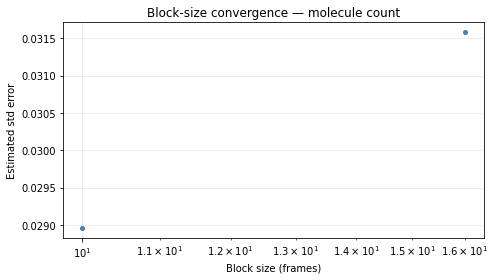

In [23]:
# Block-size convergence test: the estimated error should plateau once
# the block size exceeds the true autocorrelation time.
block_sizes = np.unique(np.geomspace(10, len(frames) // 3, num=20, dtype=int))
errors = []
for bs in block_sizes:
    try:
        s = block_average(mol_count_array, tau_corr=bs)
        errors.append(s['stderr'])
    except ValueError:
        errors.append(np.nan)

errors = np.array(errors)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(block_sizes, errors, "o-", color="steelblue", lw=1.2, ms=4)
ax.set_xlabel("Block size (frames)")
ax.set_ylabel("Estimated std error")
ax.set_title("Block-size convergence — molecule count")
plt.tight_layout()
plt.show()

**Interpretation:** The estimated error rises with block size until it flattens into a plateau.
The plateau is the true standard error — use a block size anywhere in that plateau region.
If the curve keeps rising without flattening, the trajectory is too short to estimate statistics reliably.

---
## 8 — Custom tracking with the low-level `Tracker` API

All high-level functions (`atom_hop`, `ligand_exchange`, etc.) are thin wrappers around the
generic `Tracker` class. You can use `Tracker` directly to define completely custom state functions.

The API requires two callables:
- `entity_fn(frames)` → 1-D array of entity indices to observe (called once at startup)
- `state_fn(frame, entity)` → hashable state (called for every entity at every frame)

### Example: track which atoms are unbound

An atom is *unbound* when it is the only member of its molecule (singleton molecule).
Here we detect the frames when each oxygen transitions from bonded to free radical and back.

In [24]:
from chempiler.core.tracker import Tracker
import numpy as np

tracker = Tracker(frames)

def oxygen_entities(frames):
    """Track all O atoms (indices are stable across frames)."""
    syms = frames[0].symbols
    return np.array([i for i, s in enumerate(syms) if s == "O"], dtype=np.int32)

def bonded_state(frame, atom_idx):
    """State is True if the O atom is in a molecule with >1 atom, False if isolated."""
    mol_id = frame.atom_to_mol[atom_idx]
    if mol_id < 0:
        return False
    return len(frame.molecules[mol_id]) > 1

bond_result = tracker.track(
    entity_fn=oxygen_entities,
    state_fn=bonded_state,
    persistence=2,   # require state to hold for 2 frames before recording
)

print(f"Bond-state change events: {bond_result['n_transitions']}")

if bond_result['n_transitions'] > 0:
    print("\nSample events (frame, O-atom, from, to):")
    for event in bond_result['transitions'][:5]:
        frame_idx, o_idx, from_s, to_s = event
        label = "bonded → free" if (not from_s and to_s) else "free → bonded" if (from_s and not to_s) else str((from_s, to_s))
        print(f"  frame {frame_idx:>5}  O[{o_idx}]  {label}")
else:
    print("All O atoms remained bonded throughout — expected for a stable water trajectory.")

Bond-state change events: 0
All O atoms remained bonded throughout — expected for a stable water trajectory.


### Example: track which H₂O molecules have more than 2 H-bond donors

Because `Tracker` accepts any hashable as a state, you can encode complex structural descriptors.
Here we count how many H atoms within 2.5 Å each O atom has (its total H-environment, including
hydrogen-bond donated H atoms as well as covalent ones).

In [25]:
from chempiler.core.state_field import nearest_host

tracker2 = Tracker(frames)

def h_environment(frame, o_idx):
    """Count H atoms within 2.5 Å of this O (captures covalent + H-bond H)."""
    pos = frame.positions
    h_idx = np.array([i for i, s in enumerate(frame.symbols) if s == "H"], dtype=np.int32)
    if len(h_idx) == 0:
        return 0
    diffs = pos[h_idx] - pos[o_idx]
    if frame.atoms.get_pbc().any():
        cell = np.asarray(frame.atoms.get_cell())
        diffs -= np.round(diffs @ np.linalg.inv(cell)) @ cell
    dists = np.linalg.norm(diffs, axis=1)
    return int((dists < 2.5).sum())

env_result = tracker2.track(
    entity_fn=oxygen_entities,
    state_fn=h_environment,
    persistence=1,
)

print(f"H-environment change events: {env_result['n_transitions']}")

# Distribution of H-count values seen at the end of trajectory
# (residence_times here just reflects time spent in final state)
from collections import Counter
final_states = Counter(
    h_environment(frames[-1], o)
    for o in oxygen_entities(frames)
)
print("\nH-environment distribution in the last frame:")
for n_h, count in sorted(final_states.items()):
    print(f"  {count} O atoms have {n_h} H within 2.5 Å")

H-environment change events: 31865

H-environment distribution in the last frame:
  11 O atoms have 3 H within 2.5 Å
  27 O atoms have 4 H within 2.5 Å
  1 O atoms have 5 H within 2.5 Å
  1 O atoms have 6 H within 2.5 Å


**Interpretation:** In liquid water each O atom typically has 2 covalent H neighbours and 2–3 H-bond
donated H neighbours, so an O-centred H count within 2.5 Å should peak around 4–5. The distribution
reflects the instantaneous H-bond network.

---
## Summary

| Task | Function / class |
|---|---|
| Load trajectory + cache | `ChempilerTrajectory(file).build(cache_file=...)` |
| Formula inventory | `traj.summary()` |
| Stable-composition segments | `segment_by_molecule_count(frames)` |
| Per-species lifetime segments | `traj.lifetime_segments(formula)` |
| Mean squared displacement | `traj.msd(formula, max_lag=...)` |
| RDF / coordination number | `traj.rdf(center, target, integrate=...)` |
| Proton / ion hopping | `atom_hop(frames, tracked, host, cutoff, persistence)` |
| Hop-to-species distances | `traj.hop_species_distances(hop_result, formula)` |
| Molecular identity changes | `ligand_exchange(frames)` |
| Bonding-environment changes | `coordination_dynamics(frames, atom_symbol)` |
| Statistical error bars | `block_average(values, tau_corr)` |
| Custom structural tracking | `Tracker(frames).track(entity_fn, state_fn, persistence)` |

All analyses work on standard Python lists of `Frame` objects, so you can slice, filter, or
combine frames freely before passing them to any function.